# machine learning

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
data=pd.read_csv('experience_vs_salary.csv')
data.head()

,Experience (Years),Salary ($)
0,1,30000
1,2,35000
2,3,40000
3,4,45000
4,5,50000


In [6]:
data.rename(columns={'Experience (Years)':'Experience','Salary ($)':'Salary'},inplace=True)

In [7]:
data

,Experience,Salary
0,1,30000
1,2,35000
2,3,40000
3,4,45000
4,5,50000
5,6,60000
6,7,65000
7,8,75000
8,9,85000
9,10,95000


In [8]:
X= data[['Experience']]
y=data['Salary']

### check the relationship between exp and sal

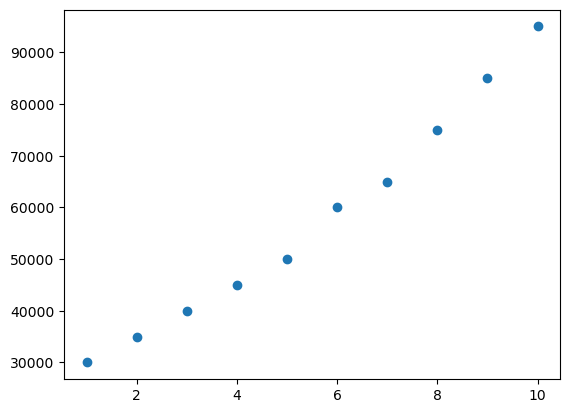

In [17]:
plt.scatter(data['Experience'],data['Salary'])
plt.show()

###### find the strength of the linear relationship

In [19]:
corr=data.corr()

In [20]:
corr

,Experience,Salary
Experience,1.000000,0.989433
Salary,0.989433,1.000000


In [10]:
X

,Experience
0,1
1,2
2,3
3,4
4,5
5,6
6,7
7,8
8,9
9,10


In [11]:
y

0    30000
1    35000
2    40000
3    45000
4    50000
5    60000
6    65000
7    75000
8    85000
9    95000
Name: Salary, dtype: int64

In [12]:
from sklearn.linear_model import LinearRegression

In [13]:
model=LinearRegression()

In [14]:
## train the model
model.fit(X,y)

LinearRegression()

In [15]:
yhat=model.predict(X)

In [16]:
yhat

array([25818.18181818, 32969.6969697 , 40121.21212121, 47272.72727273,
       54424.24242424, 61575.75757576, 68727.27272727, 75878.78787879,
       83030.3030303 , 90181.81818182])

### Evaluate the model

In [31]:
from sklearn.metrics import mean_squared_error,r2_score

In [32]:
mse=mean_squared_error(y,yhat)
rmse=np.sqrt(mse)
r_sqr=r2_score(y,yhat)
print(f'Mean Squared Error: {np.round(mse)}\nRoot Mean Squared Error:{np.round(rmse)}\nR_Squared:{np.round(r_sqr,2)}')

Mean Squared Error: 9.0
Root Mean Squared Error:3.0
R_Squared:0.88


In [33]:
a=rmse/data['Salary'].mean()

NameError: name 'data' is not defined

In [28]:
print(f'the model has: {a*100}% error')

the model has: 5.189800106982364% error


# using statsmodel- OLS

In [21]:
import statsmodels.formula.api as smf

In [22]:
model=smf.ols('Salary~Experience',data=data).fit()
model.summary()

NameError: name 'data' is not defined

In [35]:
model

## multilinear regression

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
cars=pd.read_csv('Cars_4vars.csv')

In [4]:
cars.head()

,HP,MPG,VOL,SP,WT
0,49,53.700681,89,104.185353,28.762059
1,55,50.013401,92,105.461264,30.466833
2,55,50.013401,92,105.461264,30.193597
3,70,45.696322,92,113.461264,30.632114
4,53,50.504232,92,104.461264,29.889149


### visualize the relationship

C:\Users\Vishal Parmar\anaconda34\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


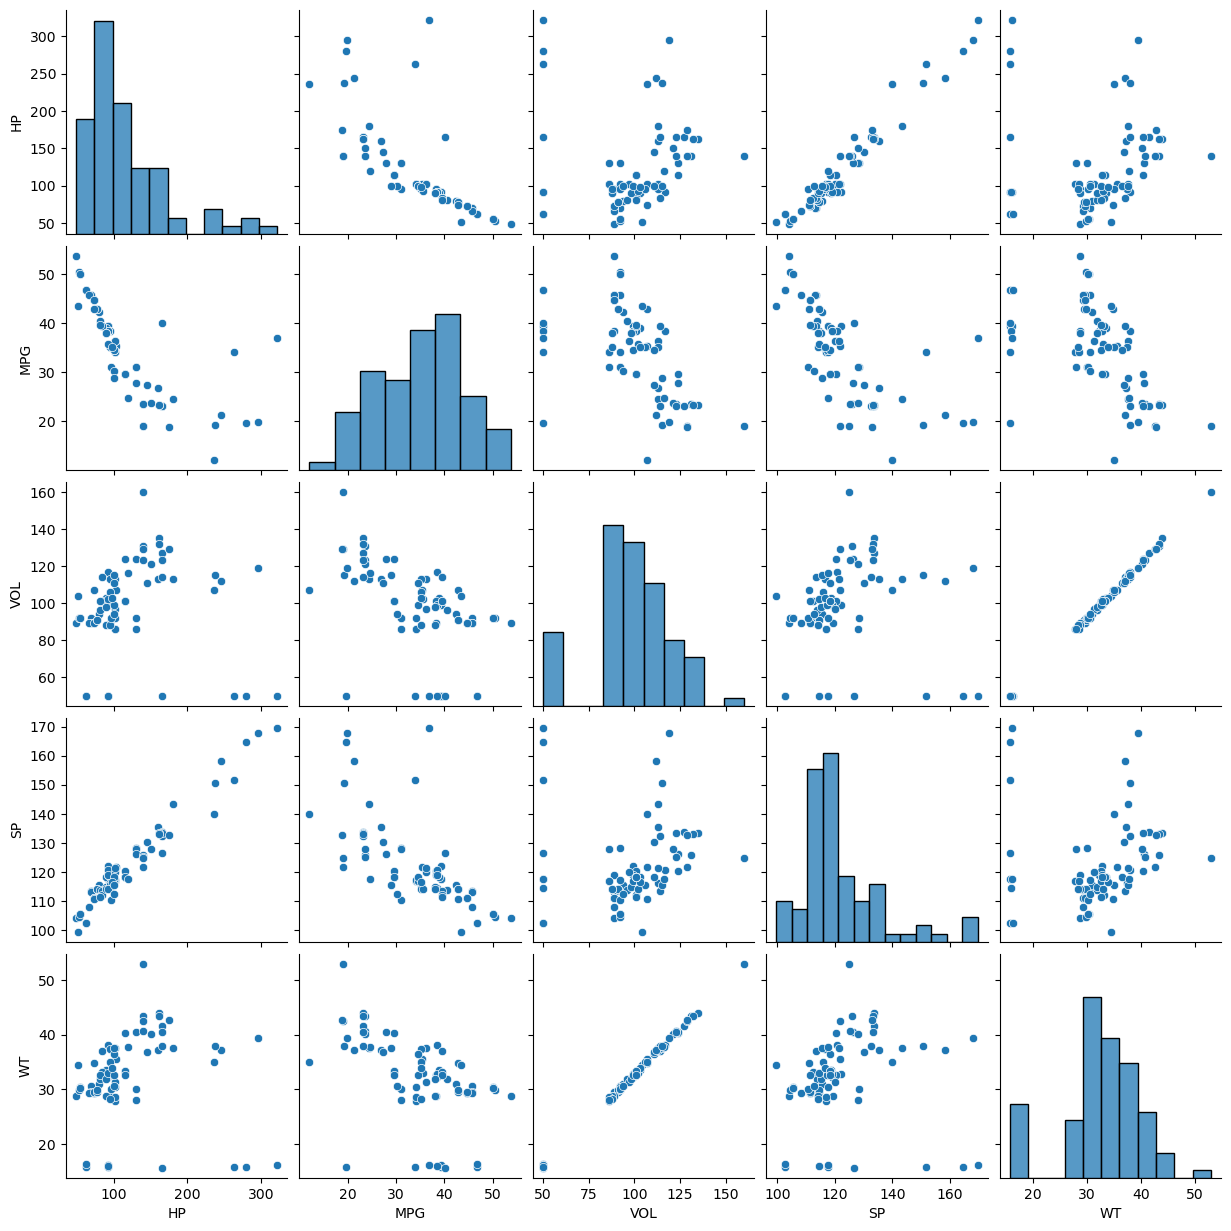

In [5]:
sns.pairplot(cars)

In [6]:
corr=cars.corr()

In [7]:
corr

,HP,MPG,VOL,SP,WT
HP,1.000000,-0.725038,0.077459,0.973848,0.076513
MPG,-0.725038,1.000000,-0.529057,-0.687125,-0.526759
VOL,0.077459,-0.529057,1.000000,0.102170,0.999203
SP,0.973848,-0.687125,0.102170,1.000000,0.102439
WT,0.076513,-0.526759,0.999203,0.102439,1.000000


<Axes: >

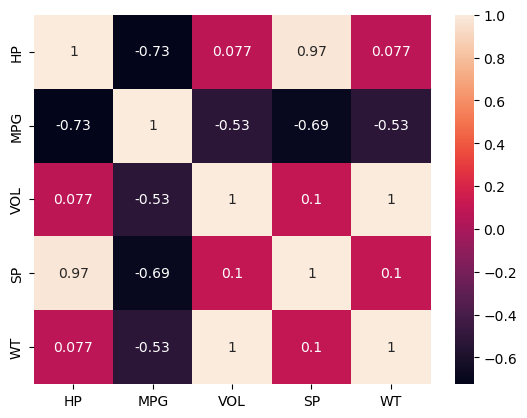

In [8]:
sns.heatmap(corr,annot=True)

In [9]:
model=smf.ols('MPG~SP+WT+VOL+HP',data=cars).fit()
model.summary()

NameError: name 'smf' is not defined

In [ ]:
wt_model=smf.ols('MPG~WT',data=cars).fit()
wt_model.summary()

In [ ]:
wtt_model=smf.ols('MPG~VOL',data=cars).fit()
wtt_model.summary()

In [ ]:
wttt_model=smf.ols('MPG~VOL+WT',data=cars).fit()
wttt_model.summary()

In [ ]:
model2=smf.ols('MPG~SP+VOL+HP',data=cars).fit()
model2.summary()

#### check for problematic records

C:\Users\Vishal Parmar\anaconda34\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


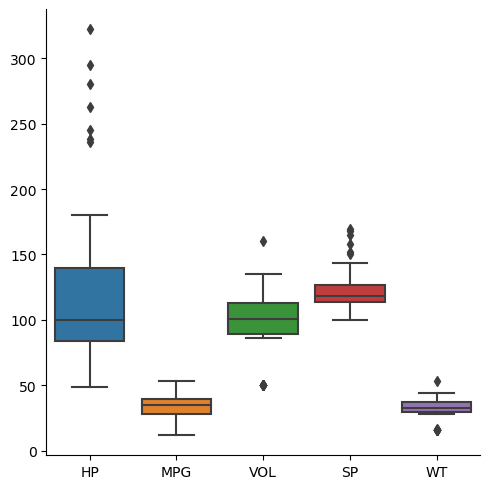

In [13]:
sns.catplot(cars,kind='box')
plt.show()

In [11]:
cars[cars['HP']>200]

,HP,MPG,VOL,SP,WT
69,245,21.273708,112,158.300669,37.141733
70,280,19.678507,50,164.598513,15.823060
76,322,36.900000,50,169.598513,16.132947
77,238,19.197888,115,150.576579,37.923113
78,263,34.000000,50,151.598513,15.769625
79,295,19.833733,119,167.944460,39.423099
80,236,12.101263,107,139.840817,34.948615


In [14]:
idx=cars[cars['HP']>200].index.values
idx

array([69, 70, 76, 77, 78, 79, 80], dtype=int64)

In [15]:
cars.drop([69, 70, 76, 77, 78, 79, 80],inplace=True)

In [16]:
cars

,HP,MPG,VOL,SP,WT
0,49,53.700681,89,104.185353,28.762059
1,55,50.013401,92,105.461264,30.466833
2,55,50.013401,92,105.461264,30.193597
3,70,45.696322,92,113.461264,30.632114
4,53,50.504232,92,104.461264,29.889149
...,...,...,...,...,...
71,162,23.203569,135,133.415985,44.013139
72,162,23.203569,132,133.140074,43.353123
73,140,19.086341,160,124.715241,52.997752
74,140,19.086341,129,121.864163,42.618698


In [17]:
cars=cars.drop('WT',axis=1)

In [18]:
cars.head()

,HP,MPG,VOL,SP
0,49,53.700681,89,104.185353
1,55,50.013401,92,105.461264
2,55,50.013401,92,105.461264
3,70,45.696322,92,113.461264
4,53,50.504232,92,104.461264


In [19]:
cars.shape

(74, 4)

In [23]:
final_model=smf.ols('MPG~VOL+WT',data=cars).fit()
final_model.summary()

PatsyError: Error evaluating factor: NameError: name 'WT' is not defined
    MPG~VOL+WT
            ^^

### using sklearn

In [25]:
from sklearn.linear_model import LinearRegression

In [26]:
x= cars.drop('MPG',axis=1)
y=cars['MPG']

In [27]:
model=LinearRegression()
model.fit(x,y)

LinearRegression()

In [29]:
yhat=model.predict(x)

### Evaluate the model

In [37]:
from sklearn.metrics import mean_squared_error, r2_score

In [38]:
mse=mean_squared_error(y,yhat)
rmse=np.sqrt(mse)
r_sqr=r2_score(y,yhat)
print(f'Mean Squared Error: {np.round(mse)}\nRoot Mean Squared Error:{np.round(rmse)}\nR_Squared:{np.round(r_sqr,2)}')

Mean Squared Error: 9.0
Root Mean Squared Error:3.0
R_Squared:0.88


In [39]:
err_pct=np.round(rmse/cars['MPG'].mean(),2)
print(f'The model has {err_pct*100}% error')


The model has 8.0% error


In [40]:
cars.shape

(74, 4)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



In [2]:
advertising=pd.read_csv('advertising.csv')

In [3]:
advertising

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Ad Topic Line,City,Male,Country,Timestamp,Clicked on Ad
0,68.95,35,61833.90,256.09,Cloned 5thgeneration orchestration,Wrightburgh,0,Tunisia,27-03-2016 00:53,0
1,80.23,31,68441.85,193.77,Monitored national standardization,West Jodi,1,Nauru,04-04-2016 01:39,0
2,69.47,26,59785.94,236.50,Organic bottom-line service-desk,Davidton,0,San Marino,13-03-2016 20:35,0
3,74.15,29,54806.18,245.89,Triple-buffered reciprocal time-frame,West Terrifurt,1,Italy,10-01-2016 02:31,0
4,68.37,35,73889.99,225.58,Robust logistical utilization,South Manuel,0,Iceland,03-06-2016 03:36,0
...,...,...,...,...,...,...,...,...,...,...
995,72.97,30,71384.57,208.58,Fundamental modular algorithm,Duffystad,1,Lebanon,11-02-2016 21:49,1
996,51.30,45,67782.17,134.42,Grass-roots cohesive monitoring,New Darlene,1,Bosnia and Herzegovina,22-04-2016 02:07,1
997,51.63,51,42415.72,120.37,Expanded intangible solution,South Jessica,1,Mongolia,01-02-2016 17:24,1
998,55.55,19,41920.79,187.95,Proactive bandwidth-monitored policy,West Steven,0,Guatemala,24-03-2016 02:35,0


In [4]:
data_org=advertising.copy()

In [5]:
data=advertising._get_numeric_data()

In [6]:
data.head()

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Male,Clicked on Ad
0,68.95,35,61833.90,256.09,0,0
1,80.23,31,68441.85,193.77,1,0
2,69.47,26,59785.94,236.50,0,0
3,74.15,29,54806.18,245.89,1,0
4,68.37,35,73889.99,225.58,0,0


In [7]:
data.rename(columns={'Daily Internet Usage':'Internet','Daily Time Spent on Site':'Time_Spent','Area Income':'area_income','Clicked on Ad':'clicked'},inplace=True)

In [8]:
data

,Time_Spent,Age,area_income,Internet,Male,clicked
0,68.95,35,61833.90,256.09,0,0
1,80.23,31,68441.85,193.77,1,0
2,69.47,26,59785.94,236.50,0,0
3,74.15,29,54806.18,245.89,1,0
4,68.37,35,73889.99,225.58,0,0
...,...,...,...,...,...,...
995,72.97,30,71384.57,208.58,1,1
996,51.30,45,67782.17,134.42,1,1
997,51.63,51,42415.72,120.37,1,1
998,55.55,19,41920.79,187.95,0,0


##### split data

In [9]:
X=data.drop('clicked',axis=1)
y=data['clicked']

### build the model

In [10]:
from sklearn.linear_model import LogisticRegression

In [11]:
# create model
model=LogisticRegression(max_iter=400)

In [12]:
#train the model
model.fit(X,y)

LogisticRegression(max_iter=400)

In [13]:
yhat=model.predict(X)

In [14]:
from sklearn.metrics import confusion_matrix, classification_report,roc_auc_score,roc_curve,precision_score,recall_score,f1_score

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

<Axes: >

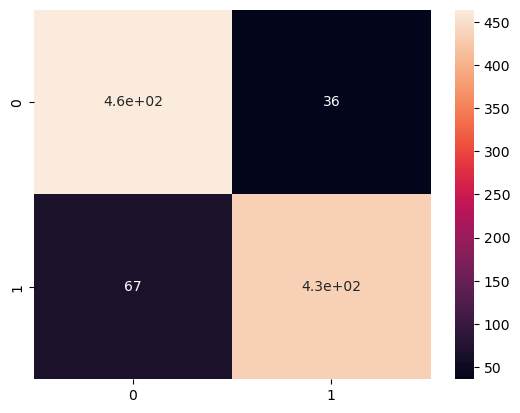

In [16]:
cm=confusion_matrix(y,yhat)
sns.heatmap(cm,annot=True)

<Axes: >

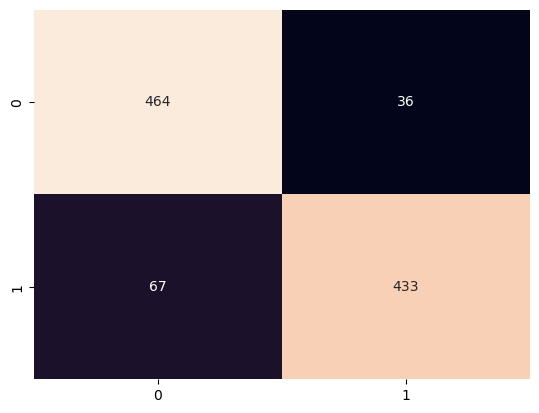

In [17]:
cm=confusion_matrix(y,yhat)
sns.heatmap(cm,annot=True,cbar=False,fmt='d')

In [18]:
def plot_roc(y,yhat):

    fpr,tpr, thresh = roc_curve(y, yhat)
    auc = roc_auc_score(y, yhat)
    print(f'AUC: {auc}')
    
    plt.figure(figsize=(3,3))
    plt.title('AUC - ROC Curve', fontsize=15)
    plt.xlabel('False Positive Rate(FPR)')
    plt.ylabel('True Positive Rate(TPR)')
    
    plt.plot(fpr,tpr)
    plt.plot([0,1],[0,1], 'o--')
    plt.show()

In [19]:
print(classification_report(y,yhat))

              precision    recall  f1-score   support

           0       0.87      0.93      0.90       500
           1       0.92      0.87      0.89       500

    accuracy                           0.90      1000
   macro avg       0.90      0.90      0.90      1000
weighted avg       0.90      0.90      0.90      1000



AUC: 0.897


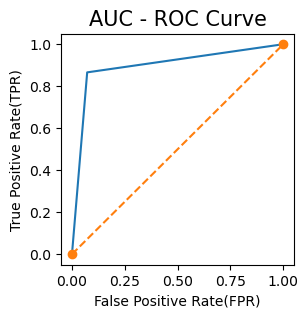

In [20]:
plot_roc(y,yhat)

In [21]:
model.predict_proba(X)
probs=pd.DataFrame(model.predict_proba(X),columns=['Will not clik','Will Click'])
probs.head()

,Will not clik,Will Click
0,0.902411,0.097589
1,0.928851,0.071149
2,0.984060,0.015940
3,0.977461,0.022539
4,0.837200,0.162800


In [22]:
def get_classes():
    cutoff=0.6
    if x>=cutoff:
        res=1
    else:
        res=0
    return res

In [23]:
probs['actual_y']=y

In [24]:
probs['y_0.6']=probs['Will Click'].apply(get_classes)

TypeError: get_classes() takes 0 positional arguments but 1 was given

In [ ]:
accuracy_score=probs['actual_y',]


# Split the data

In [ ]:
from sklearn.model_selection import train_test_split

In [25]:
X=data.drop('clicked',axis=1)
y=data['clicked']

In [26]:
X_train, X_test,y_train,y_test=train_test_split(X,y,test_size=0.2)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

NameError: name 'train_test_split' is not defined

In [27]:
model.fit(X_train,y_train)

NameError: name 'X_train' is not defined

In [28]:
yhat_train=model.predict(X_train)

NameError: name 'X_train' is not defined

In [29]:
yhat_test=model.predict(X_test)

NameError: name 'X_test' is not defined

### k fold validation

In [30]:
from sklearn.model_selection import KFold, cross_validate

In [31]:
clf=LogisticRegression(max_iter=400)

In [38]:
kfold=KFold(n_splits=5)

In [34]:
results=cross_validate(clf,X,y,cv=kfold,scoring='accuracy',return_train_score=True)
results

{'fit_time': array([0.04823399, 0.08119106, 0.01598859, 0.01629281, 0.01620555]),
 'score_time': array([0.        , 0.00799608, 0.00799465, 0.00799584, 0.        ]),
 'test_score': array([0.945, 0.96 , 0.89 , 0.885, 0.92 ]),
 'train_score': array([0.94625, 0.97125, 0.90125, 0.90125, 0.895  ])}

In [53]:
print(f"Training_accuracies: {results['train_score']}\n testing accuracies : {results['test_score']}")

Training_accuracies: [0.8968969  0.8968969  0.8968969  0.8968969  0.8968969  0.8968969
 0.8968969  0.8968969  0.95095095 0.8968969  0.8968969  0.8968969
 0.97197197 0.8968969  0.95095095 0.95395395 0.95095095 0.8988989
 0.8968969  0.8958959  0.8968969  0.8968969  0.8968969  0.95095095
 0.8968969  0.8968969  0.8968969  0.8968969  0.8958959  0.8968969
 0.95095095 0.8968969  0.8968969  0.8988989  0.8968969  0.8968969
 0.8968969  0.8958959  0.8968969  0.95095095 0.8968969  0.8968969
 0.95095095 0.8968969  0.95095095 0.8968969  0.8968969  0.8988989
 0.97197197 0.95095095 0.8968969  0.97197197 0.8968969  0.8968969
 0.95095095 0.8968969  0.8958959  0.8968969  0.8968969  0.95095095
 0.8968969  0.8978979  0.8978979  0.8978979  0.8968969  0.8968969
 0.95095095 0.8968969  0.8968969  0.8958959  0.8968969  0.8988989
 0.8968969  0.8968969  0.8968969  0.8968969  0.8968969  0.8968969
 0.95095095 0.8968969  0.8968969  0.8968969  0.8968969  0.8968969
 0.8978979  0.8968969  0.8978979  0.8968969  0.895895

### LeaveOne out validation

In [36]:
from sklearn.model_selection import LeaveOneOut

In [37]:
loocv=LeaveOneOut()

In [39]:
clf=LogisticRegression(max_iter=400)

In [40]:
kfold=KFold(n_splits=5)

In [42]:
results=cross_validate(clf,X,y,cv=loocv,scoring='accuracy',return_train_score=True)
results

{'fit_time': array([0.02423286, 0.0241003 , 0.0159924 , 0.01607156, 0.01598358,
        0.01598763, 0.01607513, 0.01599073, 0.03238893, 0.02399611,
        0.02429414, 0.01623297, 0.04050565, 0.02413154, 0.03225303,
        0.03240156, 0.03241992, 0.0240519 , 0.02398372, 0.01598811,
        0.01616502, 0.02439022, 0.01634407, 0.03247714, 0.03252053,
        0.01624036, 0.01613212, 0.01618171, 0.01599169, 0.02412581,
        0.02422166, 0.02423048, 0.01599145, 0.03238463, 0.03197885,
        0.02432537, 0.02437949, 0.01614594, 0.01629639, 0.03241825,
        0.01612568, 0.02404475, 0.04020262, 0.02440619, 0.04051447,
        0.01626611, 0.01623225, 0.01612306, 0.04048729, 0.04051375,
        0.02432418, 0.07273436, 0.02424693, 0.01620793, 0.04043913,
        0.02421761, 0.03234959, 0.03235078, 0.02439904, 0.02419305,
        0.0163331 , 0.01622748, 0.01611948, 0.01622057, 0.01610661,
        0.0162518 , 0.03230143, 0.024225  , 0.01623178, 0.01611567,
        0.02434826, 0.01613951, 0.01

In [44]:
results['test_score']

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 0., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 0., 1., 1., 1., 1., 0., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 0., 1., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 1., 1., 1., 1., 1.,
       1., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 0.

In [43]:
results['test_score'].mean()

0.905

### Shuffle split

In [45]:
from sklearn.model_selection import ShuffleSplit,cross_validate

In [49]:
ssplit=ShuffleSplit(n_splits=100,test_size=0.2,random_state= 42)

In [50]:
result=cross_validate(clf,X,y,cv=ssplit,scoring='accuracy', return_train_score=True)

In [52]:
result['test_score']

array([0.9  , 0.89 , 0.93 , 0.9  , 0.915, 0.875, 0.89 , 0.975, 0.96 ,
       0.86 , 0.885, 0.9  , 0.895, 0.855, 0.91 , 0.91 , 0.9  , 0.97 ,
       0.95 , 0.89 , 0.89 , 0.925, 0.885, 0.915, 0.925, 0.87 , 0.91 ,
       0.925, 0.895, 0.89 , 0.875, 0.9  , 0.89 , 0.935, 0.87 , 0.895,
       0.89 , 0.915, 0.875, 0.89 , 0.895, 0.87 , 0.9  , 0.895, 0.98 ,
       0.925, 0.86 , 0.91 , 0.93 , 0.97 , 0.865, 0.885, 0.905, 0.895,
       0.925, 0.91 , 0.95 , 0.915, 0.895, 0.935, 0.955, 0.9  , 0.865,
       0.925, 0.975, 0.875, 0.89 , 0.91 , 0.885, 0.9  , 0.905, 0.88 ,
       0.89 , 0.92 , 0.965, 0.92 , 0.915, 0.92 , 0.905, 0.875, 0.88 ,
       0.97 , 0.895, 0.855, 0.89 , 0.88 , 0.915, 0.895, 0.92 , 0.95 ,
       0.91 , 0.885, 0.92 , 0.925, 0.89 , 0.89 , 0.97 , 0.91 , 0.92 ,
       0.945])

### Encoding Categorical Data

In [2]:
import pandas as pd

In [3]:
iris= pd.read_csv('iris.csv')

In [4]:
iris

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [5]:
df1=iris.copy()

In [6]:
from sklearn.preprocessing import LabelEncoder

In [9]:
enc=LabelEncoder()
df1['species']=enc.fit_transform(df1['species'])
df1

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


# One hot Encoding: sklearn

In [15]:
df2=iris.copy()

In [16]:
from sklearn.preprocessing import OneHotEncoder

In [20]:
one=OneHotEncoder()
one.fit_transform(df2[['species']])

<150x3 sparse matrix of type '<class 'numpy.float64'>'
	with 150 stored elements in Compressed Sparse Row format>

In [21]:
one.fit_transform(df2[['species']]).toarray()

array([[1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0

In [22]:
one=OneHotEncoder(sparse_output=False)
one.fit_transform(df2[['species']])

array([[1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0

In [25]:
one=OneHotEncoder(sparse_output=False)
one.fit_transform(df2[['species']])

array([[1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0

In [26]:
one_df=pd.DataFrame(one.fit_transform(df2[['species']]))  ### make this a data frame with column names and then merge both dataframe i.e this one and that df2

### Using Pandas

In [27]:
df3=iris.copy()

In [28]:
df3.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [29]:
pd.get_dummies(df3,drop_first=True)

,sepal_length,sepal_width,petal_length,petal_width,species_versicolor,species_virginica
0,5.1,3.5,1.4,0.2,False,False
1,4.9,3.0,1.4,0.2,False,False
2,4.7,3.2,1.3,0.2,False,False
3,4.6,3.1,1.5,0.2,False,False
4,5.0,3.6,1.4,0.2,False,False
...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,False,True
146,6.3,2.5,5.0,1.9,False,True
147,6.5,3.0,5.2,2.0,False,True
148,6.2,3.4,5.4,2.3,False,True


In [30]:
bost= pd.read_csv('boston.csv')
bost

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,House Price
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273,21.0,393.45,6.48,22.0


In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### LinearRegression 

In [32]:
X=bost.drop('House Price',axis=1)
y=bost['House Price']

In [33]:
from sklearn.linear_model import LinearRegression,Lasso,Ridge,ElasticNet

In [34]:
lreg=LinearRegression()
lreg.fit(X,y)

LinearRegression()

In [35]:
lreg.coef_

array([-1.08011358e-01,  4.64204584e-02,  2.05586264e-02,  2.68673382e+00,
       -1.77666112e+01,  3.80986521e+00,  6.92224640e-04, -1.47556685e+00,
        3.06049479e-01, -1.23345939e-02, -9.52747232e-01,  9.31168327e-03,
       -5.24758378e-01])

In [37]:
model_params=pd.DataFrame(lreg.coef_,index=X.columns,columns=['LinearReg'])

In [38]:
model_params

,LinearReg
CRIM,-0.108011
ZN,0.046420
INDUS,0.020559
CHAS,2.686734
NOX,-17.766611
RM,3.809865
AGE,0.000692
DIS,-1.475567
RAD,0.306049
TAX,-0.012335


### Lasso Regression

In [39]:
lasso=Lasso(alpha=1.0)
lasso.fit(X,y)

Lasso()

In [40]:
lasso.coef_

array([-0.06343729,  0.04916467, -0.        ,  0.        , -0.        ,
        0.9498107 ,  0.02090951, -0.66879   ,  0.26420643, -0.01521159,
       -0.72296636,  0.00824703, -0.76111454])

In [41]:
model_params['Lasso']=lasso.coef_
model_params

,LinearReg,Lasso
CRIM,-0.108011,-0.063437
ZN,0.046420,0.049165
INDUS,0.020559,-0.000000
CHAS,2.686734,0.000000
NOX,-17.766611,-0.000000
RM,3.809865,0.949811
AGE,0.000692,0.020910
DIS,-1.475567,-0.668790
RAD,0.306049,0.264206
TAX,-0.012335,-0.015212


### Ridge Regression

In [43]:
ridge=Ridge(alpha=1.0)
ridge.fit(X,y)

Ridge()

In [44]:
ridge.coef_

array([-1.04595278e-01,  4.74432243e-02, -8.80467889e-03,  2.55239322e+00,
       -1.07770146e+01,  3.85400020e+00, -5.41453810e-03, -1.37265353e+00,
        2.90141589e-01, -1.29116463e-02, -8.76074394e-01,  9.67327945e-03,
       -5.33343225e-01])

In [45]:
model_params['Ridge']=ridge.coef_
model_params

,LinearReg,Lasso,Ridge
CRIM,-0.108011,-0.063437,-0.104595
ZN,0.046420,0.049165,0.047443
INDUS,0.020559,-0.000000,-0.008805
CHAS,2.686734,0.000000,2.552393
NOX,-17.766611,-0.000000,-10.777015
RM,3.809865,0.949811,3.854000
AGE,0.000692,0.020910,-0.005415
DIS,-1.475567,-0.668790,-1.372654
RAD,0.306049,0.264206,0.290142
TAX,-0.012335,-0.015212,-0.012912


### Elastic Net

In [46]:
elastic= ElasticNet(l1_ratio=0.5,alpha=1.0)
elastic.fit(X,y)

ElasticNet()

In [47]:
elastic.coef_

array([-0.08037077,  0.05323951, -0.0126571 ,  0.        , -0.        ,
        0.93393555,  0.0205792 , -0.76204391,  0.30156906, -0.01643916,
       -0.7480458 ,  0.00833878, -0.75842612])

In [48]:
model_params['Elastic']=elastic.coef_
model_params

,LinearReg,Lasso,Ridge,Elastic
CRIM,-0.108011,-0.063437,-0.104595,-0.080371
ZN,0.046420,0.049165,0.047443,0.053240
INDUS,0.020559,-0.000000,-0.008805,-0.012657
CHAS,2.686734,0.000000,2.552393,0.000000
NOX,-17.766611,-0.000000,-10.777015,-0.000000
RM,3.809865,0.949811,3.854000,0.933936
AGE,0.000692,0.020910,-0.005415,0.020579
DIS,-1.475567,-0.668790,-1.372654,-0.762044
RAD,0.306049,0.264206,0.290142,0.301569
TAX,-0.012335,-0.015212,-0.012912,-0.016439


ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

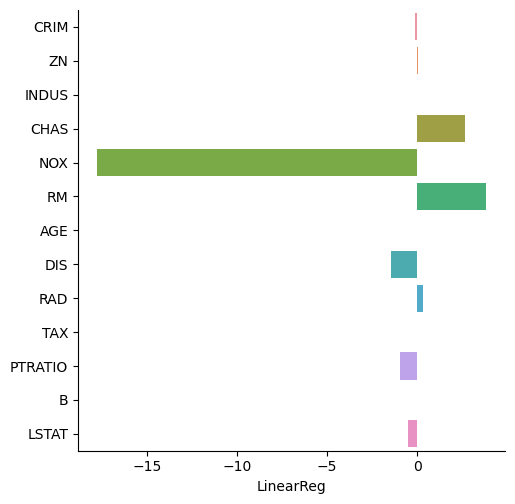

In [50]:
sns.catplot(model_params,x='LinearReg',y=model_params.index,kind='bar')
plt.show

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

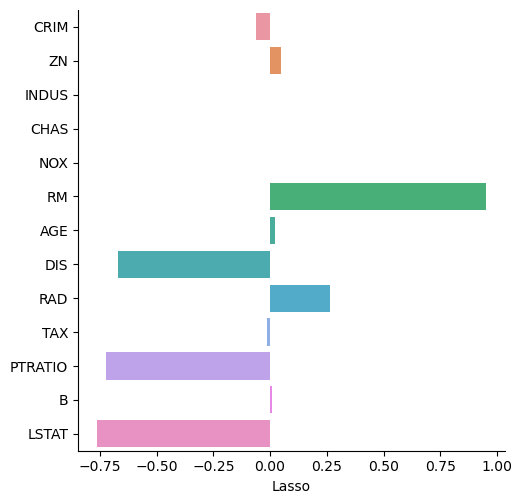

In [51]:
sns.catplot(model_params,x='Lasso',y=model_params.index,kind='bar')
plt.show

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

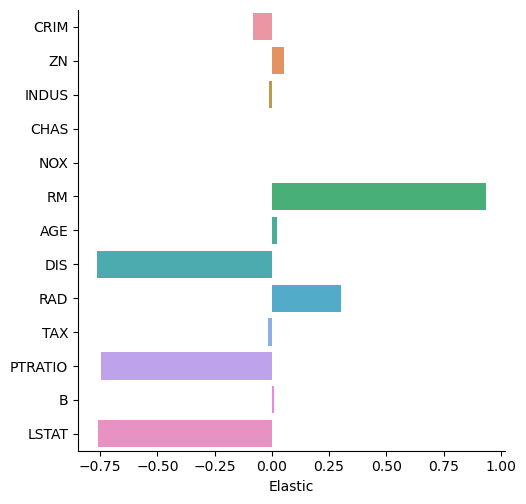

In [52]:
sns.catplot(model_params,x='Elastic',y=model_params.index,kind='bar')
plt.show